In [32]:
import shutup; shutup.please()
import scanpy as sc
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
import os

In [39]:
# adata_raw_zeng = sc.read_h5ad("/home/lemgui01/CellExtractor/data/raw_human/Zeng_biorxiv_2023_12_26_573390.h5ad")
# adata_harmonized = sc.read_h5ad("/home/lemgui01/CellExtractor/data/results_mk_1-1/harmonized/Zeng_biorxiv_2023_12_26_573390.h5ad")
adata_harmonized_park_fig1 = sc.read_h5ad("/home/lemgui01/CellExtractor/data/results_mk_1-1/harmonized/Park_science_science_aay322_fig1.h5ad")
adata_harmonized_park_stem = sc.read_h5ad("/home/lemgui01/CellExtractor/data/results_mk_1-1/harmonized/Park_science_science_aay322_stem.h5ad")
adata_harmonized = ad.concat([adata_harmonized_park_fig1, adata_harmonized_park_stem], label="study", keys=["Park_fig1", "Park_stem"], index_unique="-")

sc.pp.normalize_total(adata_harmonized, target_sum=1e6)
sc.pp.log1p(adata_harmonized)

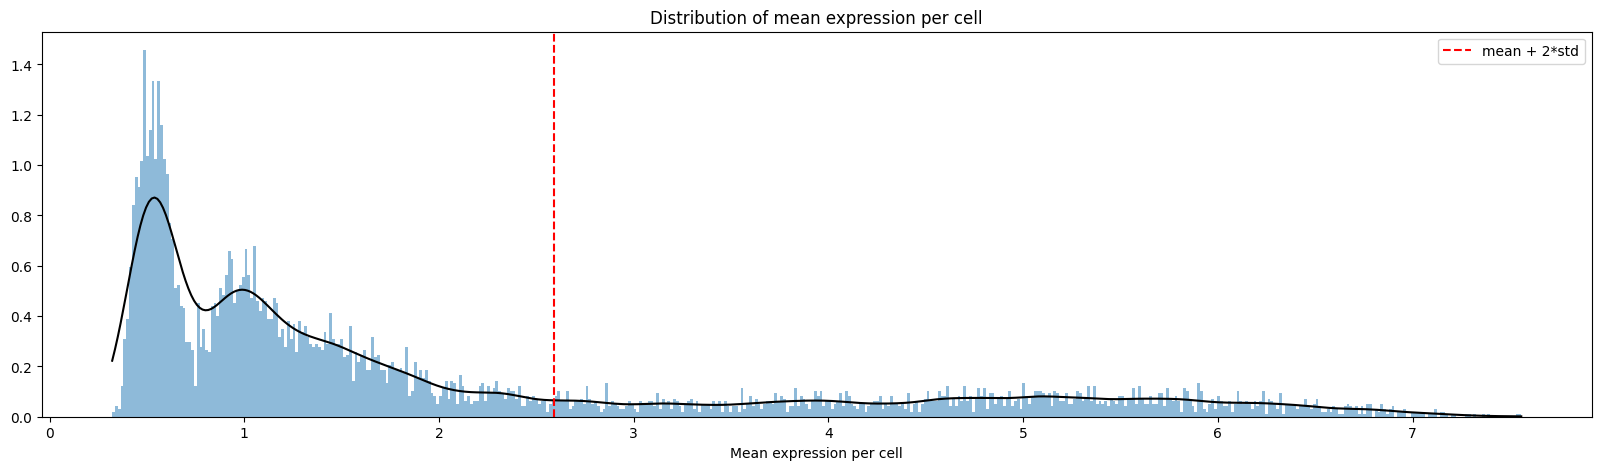

In [40]:
assign_genes = ["PPBP", "GP6", "PF4", "CD40LG", "FCGR2A", "GP1BA", "ITGB3", "ITGA2B"] # MK

adata_subset_genes = adata_harmonized[:, assign_genes].to_df()
mean_expr = adata_subset_genes.mean(axis=1)

mean_expr = np.array(mean_expr).reshape(-1, 1)
kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(mean_expr)

# Évaluer la densité sur une grille régulière
x_plot = np.linspace(mean_expr.min(), mean_expr.max(), 500)[:, None]
log_dens = kde.score_samples(x_plot)
dens = np.exp(log_dens)

# Affichage
plt.figure(figsize=(20, 5))
plt.hist(mean_expr, bins=500, density=True, alpha=0.5)
plt.plot(x_plot, dens, color="black")
plt.axvline(2.59, color="red", linestyle="--", label="mean + 2*std")
plt.xlabel("Mean expression per cell")
plt.title("Distribution of mean expression per cell")
plt.legend()
plt.show()

In [41]:
os.environ['OPENBLAS_NUM_THREADS'] = '64'

data = np.array(mean_expr).reshape(-1, 1)
gmm = GaussianMixture(n_components=2).fit(data)
probas = gmm.predict_proba(data)

means = gmm.means_.flatten()
mk_component = np.argmax(means)

proba_mk = probas[:, mk_component]

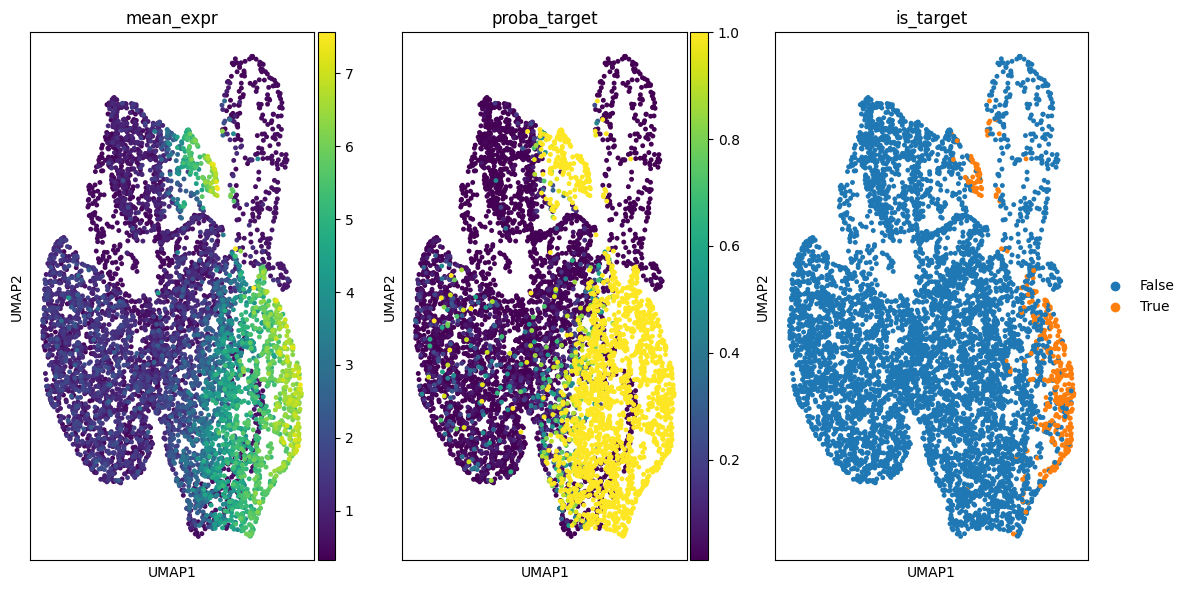

In [45]:
adata_harmonized.obs["proba_target"] = proba_mk
adata_harmonized.obs["mean_expr"] = mean_expr

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
# UMAP plots
sc.pl.umap(
    adata_harmonized,
    color="mean_expr",
    cmap="viridis",
    size=50,
    ax=ax[0],
    show=False
)
sc.pl.umap(
    adata_harmonized,
    color="proba_target",
    size=50,
    ax=ax[1],
    show=False
)

sc.pl.umap(
    adata_harmonized,
    color="is_target",
    size=50,
    ax=ax[2],
    show=False
)


fig.tight_layout()
plt.show()

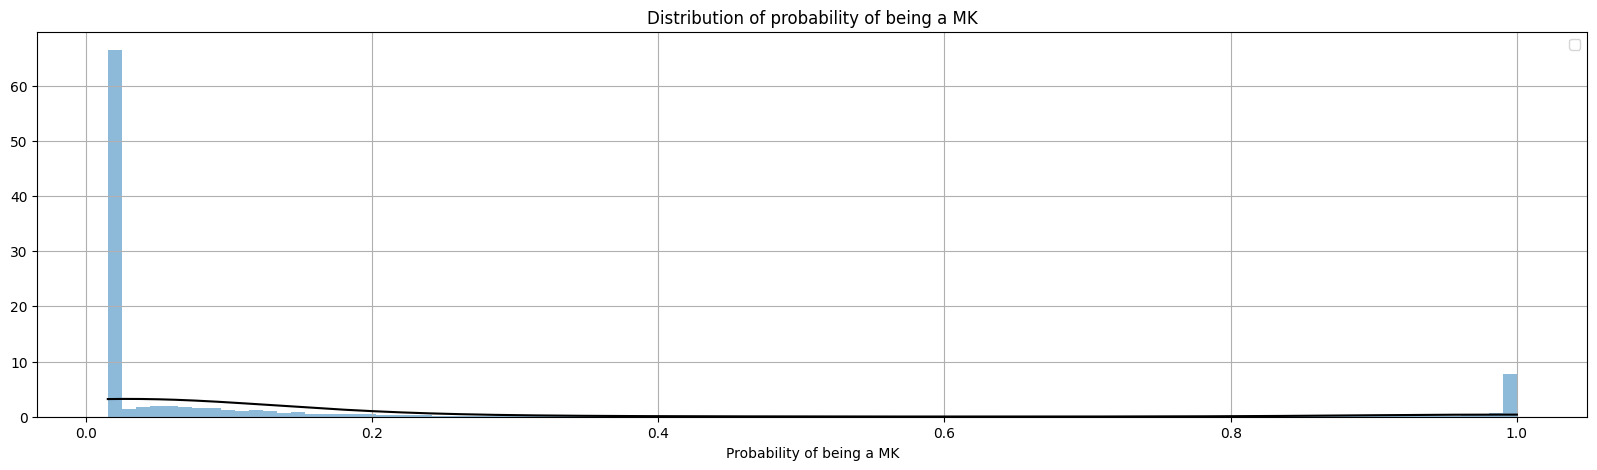

In [30]:
kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(proba_mk.reshape(-1, 1))

# Évaluer la densité sur une grille régulière
x_plot = np.linspace(proba_mk.min(), proba_mk.max(), 500)[:, None]
log_dens = kde.score_samples(x_plot)
dens = np.exp(log_dens)

# Affichage
plt.figure(figsize=(20, 5))
plt.hist(proba_mk, bins=100, density=True, alpha=0.5)
plt.plot(x_plot, dens, color="black")
plt.xlabel("Probability of being a MK")
plt.title("Distribution of probability of being a MK")
plt.legend()
plt.grid()
plt.show()